In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 18,     # x and y labels
    "axes.titlesize": 18,     # title
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
}) 


In [2]:
from halo_model.power_spectra.matter_power_baryons import MatterPowerBaryons
from halo_model.power_spectra.matter_power import MatterPower
from halo_model.power_spectra.Pm_computer import Pm_computer
from halo_model.halos.base.profile.profile import CompositeProfile

from halo_model.config.config import Config
from halo_model.halos.base.mass_converter import NFWMassConverter


In [3]:
#import ingredient models

from halo_model.halos.base.clump_mass_func.models.giocoli2010_mod import ClumpMassGiocoli2010_mod
from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010
from halo_model.halos.base.clump_mass_func.clump_mass_func import ClumpMassFunc

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.tinker2008 import MassFuncTinker2008

from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellar_truncated_powerlaw import ProfileStellarTruncatedPowerLaw
from halo_model.halos.base.profile.models.pointmass import ProfilePointMass
from halo_model.halos.base.profile.models.gas_cored_powerlaw import ProfileGasCoredPowerLaw


from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO

from halo_model.halos.base.shmr.models.moster2013 import SHMRMoster2013
from halo_model.halos.base.shmr.models.moster2013_centrals import SHMRMoster2013Centrals
from halo_model.halos.base.shmr.models.Niemiec2022 import SMHRNiemiec2022

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code/plotting_code/baryonification")) 


In [4]:
#set config & create ccl cosmology object
cfg = Config()

cfg.z = 0
cfg.N_m = 16
cfg.N_M = 32


In [5]:
c_smooth = ConcentrationNeto2007(cfg)
c_clump = ConcentrationPieri2009_clumps(c_smooth, d_vir=0.3)

mass_func = MassFuncTinker2008(cfg)

shmr = SHMRMoster2013(cfg, c_smooth)
shmr_central = SHMRMoster2013Centrals(cfg, c_smooth)
# shmr_clump = SMHRNiemiec2022(cfg, c_clump)

smooth_profile_dm = ProfileNFW(c_smooth, R_virSO(cfg))
clump_profile_dm = ProfileNFW(c_clump, R_virSO(cfg))

bias = BiasTinker2010(cfg)

clump_distribution = ProfileNFW(c_smooth, R_virSO(cfg))

clump_mass_func = ClumpMassGiocoli2010(cfg)

gas_profile = ProfileGasCoredPowerLaw(cfg, shmr, c_smooth)
stellar_profile = ProfileStellarTruncatedPowerLaw(cfg, c_smooth)

Computing Fourier transform of gas profile...
Computing Fourier transform of stellar profile...


In [6]:
cfg.M_min, cfg.M_max = 1e6, 1e16
Pm_dmo = MatterPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile_dm, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile_dm, 
                 clump_distribution=clump_distribution)

Pm_baryon = MatterPowerBaryons(cfg, 
                mass_func=mass_func, 
                shmr=shmr,
                shmr_central=shmr_central,
                smooth_profile_dm=smooth_profile_dm,
                stellar_profile=stellar_profile, 
                gas_profile=gas_profile,
                bias=bias,
                clump_mass_func=clump_mass_func, 
                clump_profile_dm=clump_profile_dm, 
                clump_distribution=clump_distribution)

k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Pm_dmo = Pm_computer(Pm_dmo, k_vals)
Pm_baryon = Pm_computer(Pm_baryon, k_vals)

interpolating Ic and Jc functions...
interpolating Ic and Jc functions...


In [7]:
from scipy.optimize import brentq

#compute matter power spectra in different mass bins

M_bins = [
    [1e10, 1e11],
    [1e11, 1e12],
    [1e12, 1e13],
    [1e13, 1e14],
    [1e14, 1e15]
]

# Note that in Debackere they use m500c mass definition, so we must convert the mass bins accordingly:
mass_converter = NFWMassConverter(cfg)

Pm_baryon_bins = []
for M_bin in M_bins:
    
    # mass converter:
    def M200m_from_M500c_finder(M500c):
        f = lambda logfrac: (
            mass_converter(
            cfg.massdef, "500c", np.exp(logfrac)*M500c, c_smooth(cfg.cosmo, np.exp(logfrac)*M500c, cfg.z), cfg.z
            ) 
            - M500c
        )
        logfrac = brentq(f, -3, 3)
        M200m = np.exp(logfrac)*M500c
        return M200m
    
    M_min, M_max = M_bin
            
    M_min = M200m_from_M500c_finder(M_min) 
    cfg.M_min = M_min
    
    M_max = M200m_from_M500c_finder(M_max) 
    cfg.M_max = M_max
        
    Pm_baryon_bin = MatterPowerBaryons(cfg, 
                    mass_func=mass_func, 
                    shmr=shmr,
                    shmr_central=shmr_central,
                    smooth_profile_dm=smooth_profile_dm,
                    stellar_profile=stellar_profile, 
                    gas_profile=gas_profile,
                    bias=bias,
                    clump_mass_func=clump_mass_func, 
                    clump_profile_dm=clump_profile_dm, 
                    clump_distribution=clump_distribution)

        
    k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)
    Pm_baryon_bin = Pm_computer(Pm_baryon_bin, k_vals)
    Pm_baryon_bins.append(Pm_baryon_bin)

interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...


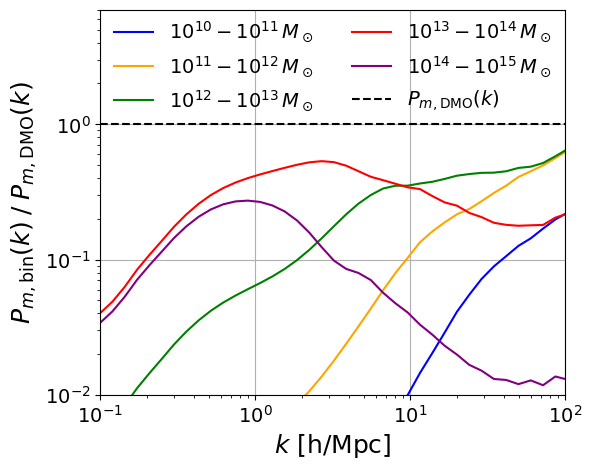

In [8]:
plt.figure(figsize=(6, 5))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for bin, Pm_baryon_bin in enumerate(Pm_baryon_bins):
    M_min, M_max = M_bins[bin]

    exp_min = int(np.log10(M_min))
    exp_max = int(np.log10(M_max))
    label = rf'$10^{{{exp_min}}} - 10^{{{exp_max}}}\,M_\odot$'
    plt.plot(k_vals, Pm_baryon_bin['P_1h']/Pm_dmo['P_tot'], label = label, linestyle='-', color=colors[bin])

plt.plot(k_vals, np.ones_like(k_vals), label = r'$P_{m,\mathrm{DMO}}(k)$', linestyle='--', color='black')
plt.yscale('log')
plt.xscale('log')

# plt.ylim(1e-3, 1e1)
# plt.xlim(np.min(k_vals), np.max(k_vals))
plt.ylim(1e-2, 7)
plt.xlim(1e-1, 1e2)

plt.xlabel(r'$k$ [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{bin}}(k) \; / \; P_{m,\mathrm{DMO}}(k)$')

plt.grid()
plt.legend(
    ncol=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    frameon=False
)

plt.xlim()

plt.savefig("Pm_baryon_1h_massbin_ratios.pdf")
plt.show()